#### Imports

In [ ]:
import numpy as np
import gradio as gr
import os
import random
import shutil
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.applications.vgg19 import preprocess_input
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.optimizers.schedules import PiecewiseConstantDecay

2025-05-11 20:44:46.507962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746985486.525422   53855 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746985486.530657   53855 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746985486.544013   53855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746985486.544037   53855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746985486.544039   53855 computation_placer.cc:177] computation placer alr

### Data Download

To use the dataset, you need to download and extract the DIV2K dataset, which contains both training and validation high-resolution images.

This script will automatically download and extract the dataset into a specified directory.

**Important:** Only run this script if you haven't already downloaded or extracted the dataset. If the dataset is already available, you can skip this step.

In [2]:
"""urls = [
    "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
    "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"
]

data_dir = "../loppuprojekti/data"
os.makedirs(data_dir, exist_ok=True)

for url in urls:
    filename = os.path.join(data_dir, os.path.basename(url))
    # Download zip file
    print(f"Downloading {url}...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print("Download ready:", filename)
    # Exctract zip file
    print(f"Extracting {filename}...")
    with ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extracted files!")

print("Data pulling ready:", data_dir)"""

'urls = [\n    "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",\n    "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"\n]\n\ndata_dir = "../loppuprojekti/data"\nos.makedirs(data_dir, exist_ok=True)\n\nfor url in urls:\n    filename = os.path.join(data_dir, os.path.basename(url))\n    # Download zip file\n    print(f"Downloading {url}...")\n    with requests.get(url, stream=True) as r:\n        r.raise_for_status()\n        with open(filename, \'wb\') as f:\n            for chunk in r.iter_content(chunk_size=8192):\n                f.write(chunk)\n    print("Download ready:", filename)\n    # Exctract zip file\n    print(f"Extracting {filename}...")\n    with ZipFile(filename, \'r\') as zip_ref:\n        zip_ref.extractall(data_dir)\n    print("Extracted files!")\n\nprint("Data pulling ready:", data_dir)'

### Data Preparation

This code splits the training dataset by moving 15% of the images from the training folder into a separate test folder

In [3]:
# For GPU logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

data_dir = "../loppuprojekti/data"
train = "../loppuprojekti/data/DIV2K_train_HR/"
validation = "../loppuprojekti/data/DIV2K_valid_HR/"
test = "../loppuprojekti/data/DIV2K_test_HR"

os.makedirs(test, exist_ok=True)

train_files = os.listdir(train)

num_test_files = int(len(train_files) * 0.15)

files_to_move = random.sample(train_files, num_test_files)

if not os.listdir(test):
    for file in files_to_move:
        src = os.path.join(train, file)
        dst = os.path.join(test, file)
        shutil.move(src, dst)

    print(f"Moved {len(files_to_move)} files to test directory")

else:
    print("Test files already exist")

Test files already exist


#### Data Augmentation Helper Functions

These functions apply random data augmentation techniques to both low-resolution (LR) and high-resolution (HR) images, which helps improve the model's generalization during training.

In [ ]:
def flip_left_right(lowres_img, highres_img):
    """Flips Images to left and right."""

    # Outputs random values from a uniform distribution in between 0 to 1
    rn = tf.random.uniform(shape=(), maxval=1.0)

    # If rn is less than 0.5 it returns original lowres_img and highres_img
    # If rn is greater than 0.5 it returns flipped image
    return tf.cond(
        rn < 0.5,
        lambda: (lowres_img, highres_img),
        lambda: (
            tf.image.flip_left_right(lowres_img),
            tf.image.flip_left_right(highres_img),
        ),
    )


def random_rotate(lowres_img, highres_img):
    """Rotates Images by 90 degrees."""

    # Outputs random values from uniform distribution in between 0 to 4
    rn = tf.cast(
        tf.random.uniform(shape=(), maxval=4, dtype=tf.float32), dtype=tf.int32
    )

    # Here rn signifies number of times the image(s) are rotated by 90 degrees
    return tf.image.rot90(lowres_img, rn), tf.image.rot90(highres_img, rn)

#### Utility Functions

This cell defines reusable components used throughout the project. It includes the pre-trained VGG19 feature extractor and a combined perceptual-pixel loss function used during training, as well as helper functions and custom layers for model evaluation and serialization.

In [5]:
vgg = keras.applications.VGG19(include_top=False, weights="imagenet")
vgg.trainable = False
vgg_model = Model(inputs=vgg.input, outputs=vgg.get_layer("block3_conv3").output)


def preprocess_vgg(x):
    x = tf.image.resize(x, [224, 224])
    x = preprocess_input(x * 255.0)
    return x


def combined_loss(y_true, y_pred):
    # Preprocess for VGG
    y_true_vgg = preprocess_vgg(y_true)
    y_pred_vgg = preprocess_vgg(y_pred)

    # Extract features
    f_true = vgg_model(y_true_vgg)
    f_pred = vgg_model(y_pred_vgg)

    # Perceptual loss: feature-wise MSE
    perceptual = tf.reduce_mean(tf.square(f_true - f_pred))

    # Normalize perceptual loss
    perceptual /= tf.cast(tf.size(f_true), tf.float32)

    pixel = tf.reduce_mean(tf.abs(y_true - y_pred))
    return 20 * perceptual + 1.0 * pixel


@register_keras_serializable()
class PixelShuffle(layers.Layer):
    def __init__(self, scale, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        return tf.nn.depth_to_space(inputs, block_size=self.scale)

    def get_config(self):
        config = super().get_config()
        config.update({"scale": self.scale})
        return config


@register_keras_serializable()
def load_model(filepath):
    return keras.models.load_model(
        filepath,
        custom_objects={
            "PixelShuffle": PixelShuffle,
            "combined_loss": combined_loss,
            "PSNR": PSNR,
            "SSIM": SSIM,
            "PiecewiseConstantDecay": PiecewiseConstantDecay,
        },
    )


@register_keras_serializable()
def PSNR(original, generated):
    return tf.image.psnr(original, generated, max_val=1.0)


@register_keras_serializable()
def SSIM(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

I0000 00:00:1746985490.629010   53855 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6687 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:0a:00.0, compute capability: 6.1


#### Dataset Creation

We create the dataset by applying random cropping to each high-resolution image. While this technique is not ideal for evaluating performance on full-size images, it provides a fast and memory-efficient way to train the model using smaller, diverse patches.

Each cropped patch is:
- Downscaled to simulate a low-resolution version (input).
- Paired with the original high-resolution patch (target).

This setup allows the model to learn super-resolution mappings using small image patches, which significantly reduces computational overhead during training.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
crop_size = 192
scale = 4

train_dir = os.path.join(data_dir, "DIV2K_train_HR")
val_dir = os.path.join(data_dir, "DIV2K_valid_HR")
test_dir = os.path.join(data_dir, "DIV2K_test_HR")

train_files = [
    os.path.join(train_dir, fname)
    for fname in os.listdir(train_dir)
    if fname.lower().endswith((".png", ".jpg", ".jpeg"))
]

val_files = [
    os.path.join(val_dir, fname)
    for fname in os.listdir(val_dir)
    if fname.lower().endswith((".png", ".jpg", ".jpeg"))
]

test_files = [
    os.path.join(test_dir, fname)
    for fname in os.listdir(test_dir)
    if fname.lower().endswith((".png", ".jpg", ".jpeg"))
]


def random_crop_and_downscale(hr_img):
    hr_patch = tf.image.random_crop(hr_img, size=[crop_size, crop_size, 3])
    hr_patch.set_shape([crop_size, crop_size, 3])

    # Randomly apply blur
    if tf.random.uniform(()) > 0.5:
        hr_patch = tf.nn.avg_pool(hr_patch[None], ksize=3, strides=1, padding="SAME")[0]
    # Add random noise
    noise = tf.random.normal(tf.shape(hr_patch), mean=0.0, stddev=0.01)
    hr_patch = tf.clip_by_value(hr_patch + noise, 0.0, 1.0)

    lr_patch = tf.image.resize(
        hr_patch, [crop_size // scale, crop_size // scale], method="area"
    )
    lr_patch.set_shape([crop_size // scale, crop_size // scale, 3])
    return lr_patch, hr_patch


# Build datasets
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    return tf.image.convert_image_dtype(img, tf.float32)


train_ds = tf.data.Dataset.from_tensor_slices(train_files).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE
)


val_ds = tf.data.Dataset.from_tensor_slices(val_files).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE
)


test_ds = tf.data.Dataset.from_tensor_slices(test_files).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE
)


# Apply random cropping and downscaling
BATCH_SIZE = 2

train_sr = train_ds.map(random_crop_and_downscale, num_parallel_calls=tf.data.AUTOTUNE)
train_sr = train_sr.map(random_rotate, num_parallel_calls=tf.data.AUTOTUNE)
train_sr = train_sr.map(flip_left_right, num_parallel_calls=tf.data.AUTOTUNE)
train_sr = train_sr.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_sr = val_ds.map(random_crop_and_downscale, num_parallel_calls=tf.data.AUTOTUNE)
val_sr = val_sr.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_sr = test_ds.map(random_crop_and_downscale, num_parallel_calls=tf.data.AUTOTUNE)
test_sr = test_sr.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Example: print shapes

for lr, hr in train_sr.take(1):
    print("LR patch shape:", lr.shape)
    print("HR patch shape:", hr.shape)
#### Plot Example of Training Data

LR patch shape: (2, 48, 48, 3)
HR patch shape: (2, 192, 192, 3)


2025-05-11 20:44:53.230972: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


The image pair below illustrates a low-resolution input and its corresponding high-resolution target, as used across training, validation, and test datasets.

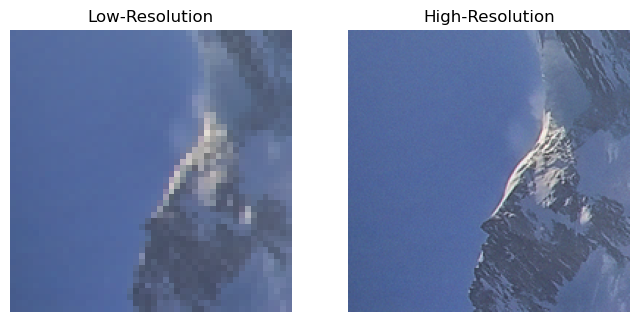

2025-05-11 20:44:54.067444: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# Get one LR-HR pair from the dataset
for lr, hr in train_sr.take(1):
    lr_img = lr.numpy()
    hr_img = hr.numpy()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Low-Resolution")
    plt.imshow(lr_img[0])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("High-Resolution")
    plt.imshow(hr_img[0])
    plt.axis("off")

    plt.show()

#### Callbacks

This cell defines training callbacks to improve model performance and prevent overfitting.

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",  # or val_calculate_psnr for PSNR
    patience=20,
    restore_best_weights=True,
    mode="min",
)

#### Model Construction

Defines the architecture of the super-resolution model, including residual blocks for feature learning and upsampling layers for image resolution enhancement. The `make_model` function builds and returns the full model.

In [ ]:
# Up sampling layer
def Upsampling(inputs, factor=2, **kwargs):
    x = layers.Conv2D(64 * (factor**2), 3, padding="same", **kwargs)(inputs)
    x = PixelShuffle(factor)(x)
    x = layers.Conv2D(64 * (factor**2), 3, padding="same", **kwargs)(x)
    x = PixelShuffle(factor)(x)
    return x


def SRGAN_ResBlock(inputs, filters):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([inputs, x])
    return x


def build_srgan_generator(num_filters=64, num_res_blocks=16, scale=4):
    input_layer = layers.Input(shape=(None, None, 3))
    x = layers.Conv2D(num_filters, 9, padding="same")(input_layer)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    res = x

    # Add residual blocks
    for _ in range(num_res_blocks):
        res = SRGAN_ResBlock(res, num_filters)

    res = layers.Conv2D(num_filters, 3, padding="same")(res)
    res = layers.BatchNormalization()(res)
    x = layers.Add()([x, res])

    # Add Upsampling blocks
    for _ in range(int(np.log2(scale))):
        x = layers.Conv2D(num_filters * 4, 3, padding="same")(x)
        x = PixelShuffle(2)(x)
        x = layers.PReLU(shared_axes=[1, 2])(x)

    output_layer = layers.Conv2D(3, 9, padding="same", activation="tanh")(x)
    return Model(inputs=input_layer, outputs=output_layer)


generator = build_srgan_generator(num_filters=64, num_res_blocks=16, scale=4)

In [10]:
# SRGAN discriminator
def build_srgan_discriminator(input_shape=(None, None, 3), num_filters=64):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(num_filters, 3, strides=1, padding="same")(inp)
    x = layers.LeakyReLU(0.2)(x)

    filters = num_filters
    for i in range(1, 4):
        x = layers.Conv2D(filters, 3, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        filters *= 2

    x = layers.Flatten()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return Model(inp, out)


discriminator = build_srgan_discriminator(input_shape=(192, 192, 3), num_filters=64)

In [ ]:
# Custom loss function for SRGAN

generator_optimizer = Adam(1e-4)
discriminator_optimizer = Adam(5e-7)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)


def discriminator_loss(real_output, fake_output):
    real_labels = tf.random.uniform(tf.shape(real_output), 0.8, 1.0)
    fake_labels = tf.random.uniform(tf.shape(fake_output), 0.0, 0.2)
    real_loss = bce(real_labels, real_output)
    fake_loss = bce(fake_labels, fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output, sr, hr):
    adv_loss = bce(tf.ones_like(fake_output), fake_output)

    # Perceptual loss
    vgg_hr = vgg_model(preprocess_vgg(hr))
    vgg_sr = vgg_model(preprocess_vgg(sr))
    perceptual_loss = tf.reduce_mean(tf.square(vgg_hr - vgg_sr))

    pixel_loss = tf.reduce_mean(tf.abs(hr - sr))

    return 2e-5 * adv_loss + 0.006 * perceptual_loss + pixel_loss


@tf.function
def train_step(lr, hr):

    with tf.GradientTape(persistent=True) as tape:
        sr = generator(lr, training=True)
        real_output = discriminator(hr, training=True)
        fake_output = discriminator(sr, training=True)

        # tf.print("real_output mean:", tf.reduce_mean(real_output))
        # tf.print("fake_output mean:", tf.reduce_mean(fake_output))
        # tf.print("real_output sample:", tf.reshape(real_output, [-1])[:10])
        # tf.print("fake_output sample:", tf.reshape(fake_output, [-1])[:10])

        d_loss = discriminator_loss(real_output, fake_output)
        g_loss = generator_loss(fake_output, sr, hr)

        grads_g = tape.gradient(g_loss, generator.trainable_variables)
        grads_d = tape.gradient(d_loss, discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
        discriminator_optimizer.apply_gradients(
            zip(grads_d, discriminator.trainable_variables)
        )

        return g_loss, d_loss

In [ ]:
# Pretrain for srgan model
generator.compile(optimizer=Adam(learning_rate=1e-4), loss="mae", metrics=[PSNR, SSIM])
generator.fit(
    train_sr, validation_data=val_sr, epochs=100, callbacks=[early_stop, reduce_lr]
)

generator.save_weights("mae_pretrained.weights.h5")

In [ ]:
generator.load_weights("mae_pretrained.weights.h5")

In [ ]:
from rich.progress import Progress
import time


# SRGAN train
def validate(generator, val_sr):
    psnr_vals, ssim_vals = [], []
    for lr, hr in val_sr:
        sr = generator(lr, training=False)
        psnr_vals.append(tf.reduce_mean(PSNR(hr, sr)).numpy())
        ssim_vals.append(tf.reduce_mean(SSIM(hr, sr)).numpy())
    return np.mean(psnr_vals), np.mean(ssim_vals)


def train(patience=20, epoch=200):
    start_time = time.time()
    best_ssim = -np.inf
    patience = 20
    wait = 0
    EPOCHS = epoch
    g_losses_history, d_losses_history = [], []

    with Progress(transient=False) as progress:
        for epoch in range(EPOCHS):
            g_losses, d_losses = [], []
            num_batches = len(list(train_sr))

            task = progress.add_task(f"[cyan]Epoch {epoch+1}", total=num_batches)
            for batch_idx, (lr, hr) in enumerate(train_sr):
                g_loss, d_loss = train_step(lr, hr)
                g_losses.append(g_loss.numpy())
                d_losses.append(d_loss.numpy())
                progress.update(
                    task,
                    advance=1,
                    description=f"[cyan]Epoch {epoch+1}/{EPOCHS} | Batch: {batch_idx+1}/{num_batches} d_loss {d_loss:.3f}]",
                )

            # Validation
            val_psnr, val_ssim = validate(generator, val_sr)
            elapsed = int(time.time() - start_time)
            elapsed_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
            desc = (
                f"[cyan]Epoch {epoch+1}"
                f"[green] g_loss {np.mean(g_losses):.3f} d_loss {np.mean(d_losses):.3f}  PSNR: {val_psnr:.3f} | SSIM: {val_ssim:.3f}[/green]"
                f"[cyan]/{elapsed_str}[/cyan]"
            )
            progress.update(task, description=desc)

            g_losses_history.append(np.mean(g_losses))
            d_losses_history.append(np.mean(d_losses))

            # Reduce learning rate
            if wait > 0 and wait % 5 == 0:
                old_lr = generator_optimizer.learning_rate.numpy()
                new_lr = max(old_lr * 0.5, 1e-6)
                generator_optimizer.learning_rate.assign(new_lr)
                discriminator_optimizer.learning_rate.assign(new_lr)
                progress.console.print(f"[red]Reduced learning rate to {new_lr}[/red]")

            # Early stop with ssim
            if val_ssim > best_ssim:
                best_ssim = val_ssim
                wait = 0
                generator.save("srgan_generator_best.keras")
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stop activated at epoch {epoch+1}")
                    break

        return (g_losses_history, d_losses_history)


history = train(epoch=200, patience=20)
generator.save("srgan_generator.keras")

Output()

2025-05-11 20:45:25.430663: W external/local_xla/xla/stream_executor/integrations/stream_executor_allocator.cc:50] could not allocate pinned host memory of size: 1073741824


2025-05-11 20:45:26.537093: W external/local_xla/xla/stream_executor/integrations/stream_executor_allocator.cc:50] could not allocate pinned host memory of size: 966367744


2025-05-11 20:45:27.672765: W external/local_xla/xla/stream_executor/integrations/stream_executor_allocator.cc:50] could not allocate pinned host memory of size: 869731072


2025-05-11 20:45:28.787784: W external/local_xla/xla/stream_executor/integrations/stream_executor_allocator.cc:50] could not allocate pinned host memory of size: 782758144


...

Reduced learning rate to 4.999999873689376e-05

Reduced learning rate to 2.499999936844688e-05

2025-05-11 21:31:30.925812: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Reduced learning rate to 1.249999968422344e-05

Early stop activated at epoch 25

In [ ]:
# Load generator
generator = keras.models.load_model(
    "srgan_generator_best.keras",
    custom_objects={
        "PixelShuffle": PixelShuffle,
        "combined_loss": combined_loss,
        "PSNR": PSNR,
        "SSIM": SSIM,
        "PiecewiseConstantDecay": PiecewiseConstantDecay,
    },
)

In [ ]:
# Define evaluation function
def evaluate(generator, test_sr):
    psnr_vals, ssim_vals = [], []
    for lr, hr in test_sr:
        sr = generator(lr, training=False)
        psnr_vals.append(tf.reduce_mean(PSNR(hr, sr)).numpy())
        ssim_vals.append(tf.reduce_mean(SSIM(hr, sr)).numpy())
    print(f"Test PSNR: {np.mean(psnr_vals):.4f}")
    print(f"Test SSIM: {np.mean(ssim_vals):.4f}")


evaluate(generator, test_sr)

Test PSNR: 27.3398
Test SSIM: 0.7092


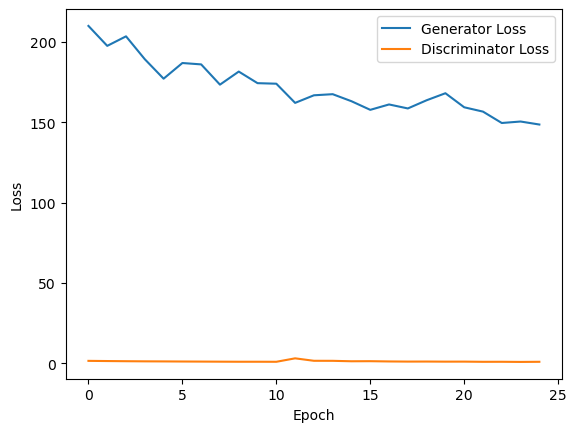

In [ ]:
g_losses_history, d_losses_history = history

plt.plot(g_losses_history, label="Generator Loss")
plt.plot(d_losses_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.007497611..0.72524536].


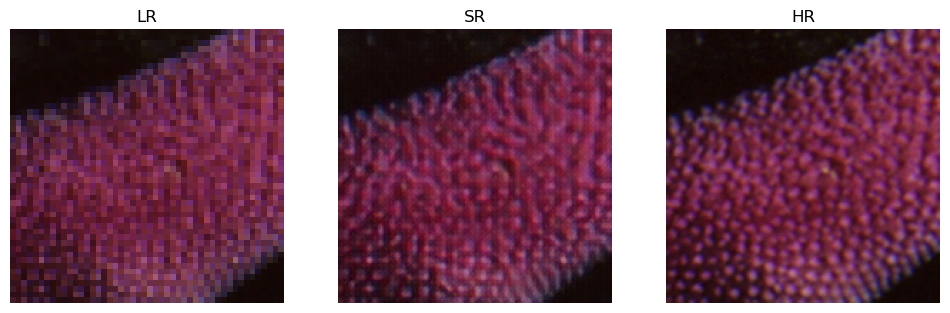

In [ ]:
# Plot one batch of results

for lr, hr in test_sr.take(1):
    sr = generator(lr, training=False)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("LR")
    plt.imshow(lr[0].numpy())
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("SR")
    plt.imshow((sr[0].numpy() + 1) / 2)  # for tanh output
    plt.imshow(sr[0].numpy())
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("HR")
    plt.imshow(hr[0].numpy())
    plt.axis("off")
    plt.show()

In [ ]:
%pip install gdown
import gdown

def download_model_from_drive(model_path="super_resolution_model.keras", file_id=None):
    if os.path.exists(model_path):
        print(f"Model already exists at {model_path}")
        return

    if file_id is None:
        raise ValueError("file_id is required to download the model.")

    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading model from {url}...")
    gdown.download(url, model_path, quiet=False)

#download_model_from_drive(file_id="1c2jvn_g-inZwMBd_vvbj4-qQLwfhIq3Z") # legacy .h5 format
download_model_from_drive(file_id="1vrXrsplXC0FuTyOZ4y3sQ-TRQQEWW-R9") # Keras 3 format

saved_model = load_model("super_resolution_modelTEST.keras")

In [ ]:
saved_model = load_model("super_resolution_modelTEST.keras")

In [ ]:
def super_resolve_large_image(model, input_img, patch_size=256, overlap=32):
    """
    Super-resolve a large image by tiling it into patches.
    Args:
        model: Trained super-resolution model.
        input_img: NumPy array, shape (H, W, 3), float32 in [0,1].
        patch_size: Size of each patch to process.
        overlap: Overlap between patches to avoid seams.
    Returns:
        Super-resolved image as NumPy array.
    """
    h, w, c = input_img.shape
    scale = 4  # Change if your model uses a different scale

    out_h, out_w = h * scale, w * scale
    output_img = np.zeros((out_h, out_w, c), dtype=np.float32)
    weight_mask = np.zeros((out_h, out_w, c), dtype=np.float32)

    stride = patch_size - overlap
    for y in range(0, h, stride):
        for x in range(0, w, stride):
            patch = input_img[y : y + patch_size, x : x + patch_size, :]
            patch_h, patch_w = patch.shape[:2]
            patch_input = np.expand_dims(patch, axis=0)
            sr_patch = model.predict(patch_input)[0]
            y1, x1 = y * scale, x * scale
            y2, x2 = y1 + patch_h * scale, x1 + patch_w * scale
            output_img[y1:y2, x1:x2, :] += sr_patch[
                : patch_h * scale, : patch_w * scale, :
            ]
            weight_mask[y1:y2, x1:x2, :] += 1.0

    # Avoid division by zero
    output_img /= np.maximum(weight_mask, 1e-8)
    return np.clip(output_img, 0, 1)


def superRes(input_img):

    img_array = input_img.astype(np.float32) / 255.0
    sr_img = super_resolve_large_image(generator, img_array, patch_size=256, overlap=32)
    return (sr_img * 255).astype(np.uint8)


demo = gr.Interface(fn=superRes, inputs=gr.Image(type="numpy"), outputs="image")


if __name__ == "__main__":

    demo.launch(share=True)